# Euroleague Players Cluster Analysis
## Redefining Positions Through Unsupervised Learning

This notebook applies unsupervised learning to EuroLeague player-season data (2020/2021–2024/2025) to identify data-driven play-style positions beyond the traditional five. The analysis is inspired by Kalman & Bosch (2019), *"NBA Lineup Analysis on Clustered Player Tendencies"*, which used model-based clustering to redefine player roles in the NBA.

### Methodology
1. **Data filtering** — minimum minutes threshold for reliable rate stats
2. **Scaling** — StandardScaler to normalize variables of different scales
3. **K-Means** — as a baseline (with silhouette analysis)
4. **Model-Based Clustering (GMM)** — primary method, using BIC for model selection (number of clusters + covariance structure)
5. **Cluster profiling** — box plots of scaled variables, position description table, example players
6. **Soft assignment analysis** — probabilistic cluster membership

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/processed/final_dataset_2020_2024.csv')
print(f"Dataset: {df.shape[0]} player-seasons, {df.shape[1]} variables")
print(f"Seasons: {sorted(df['season'].unique())}")
df.head(3)

Dataset: 956 player-seasons, 26 variables
Seasons: [2020, 2021, 2022, 2023, 2024]


,player.name,season,player.team.code,player.team.tvCodes,player.team.name,minutesPlayed,Height,offensiveReboundsPercentage,defensiveReboundsPercentage,assistsRatio,...,freeThrowsRate,freeThrowsPercentage,fieldGoalsAttempted,twoPointersPercentage,threePointersPercentage,3FGA_Pct,Corner_3FGA_Pct,0_1m_FGA_Pct,1_3.5m_FGA_Pct,3.5m_3pt_FGA_Pct
0,"KURUCS, ARTURS",2020,BAS,TDS,Baskonia Vitoria-Gasteiz,4.196032,193.0,0.067,0.027,0.234,...,0.250,0.600,58.5,0.125,0.250,60.00,16.67,5.00,30.00,5.00
1,"DIOP, ILIMANE",2020,BAS,TDS,Baskonia Vitoria-Gasteiz,6.720370,211.0,0.067,0.174,0.111,...,0.353,0.583,47.1,0.368,0.333,44.12,0.00,11.76,35.29,8.82
2,"FRIDZON, VITALY",2020,DYR,ZEN,Zenit St Petersburg,5.360556,195.0,0.042,0.112,0.152,...,0.194,0.833,58.9,0.533,0.312,51.61,25.00,0.00,22.58,25.81


## 1. Data Filtering — Minimum Minutes Threshold

We filter by average minutes per game. Players with very few minutes produce unstable rate statistics (e.g., shooting percentages of 0% or 100%).

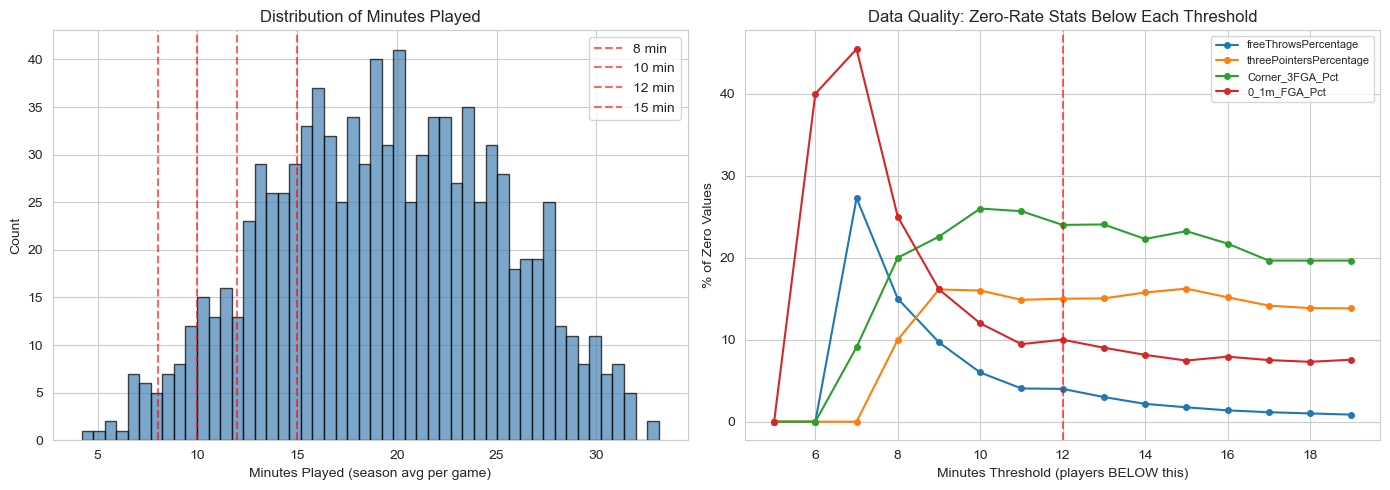


Players retained at each threshold:
  >=  8 min:   936 players (97.9%)
  >= 10 min:   906 players (94.8%)
  >= 12 min:   856 players (89.5%)
  >= 15 min:   728 players (76.2%)


In [61]:
# Minutes distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['minutesPlayed'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
for t in [8, 10, 12, 15]:
    axes[0].axvline(t, color='red', linestyle='--', alpha=0.6, label=f'{t} min')
axes[0].set_xlabel('Minutes Played (season avg per game)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Minutes Played')
axes[0].legend()

# Data quality: % of zeros in key rate stats below each threshold
rate_cols = ['freeThrowsPercentage', 'threePointersPercentage', 'Corner_3FGA_Pct', '0_1m_FGA_Pct']
thresholds = range(5, 20)
quality = {col: [] for col in rate_cols}
for t in thresholds:
    below = df[df['minutesPlayed'] < t]
    for col in rate_cols:
        quality[col].append((below[col] == 0).mean() * 100 if len(below) > 0 else 0)

for col in rate_cols:
    axes[1].plot(list(thresholds), quality[col], marker='o', markersize=4, label=col)
axes[1].set_xlabel('Minutes Threshold (players BELOW this)')
axes[1].set_ylabel('% of Zero Values')
axes[1].set_title('Data Quality: Zero-Rate Stats Below Each Threshold')
axes[1].legend(fontsize=8)
axes[1].axvline(12, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\nPlayers retained at each threshold:")
for t in [8, 10, 12, 15]:
    n = (df['minutesPlayed'] >= t).sum()
    print(f"  >= {t:2d} min: {n:5d} players ({100*n/len(df):.1f}%)")

### Minutes Threshold Decision: 12 minutes

- Below 12 min, ~27% of players have zero Corner 3FGA%, ~21% zero 3PT% — rate stats are unreliable
- 12 min retains **~89% of the data** (~856 player-seasons)
- Standard "rotation player" threshold in basketball analytics

In [62]:
# ========== CONFIGURATION ==========
MIN_MINUTES = 12

CLUSTER_VARS = [
    'Height',
    'offensiveReboundsPercentage',
    'defensiveReboundsPercentage',
    'assistsRatio',
    'turnoversRatio',
    'blocks',
    'steals',
    'pointsScored',
    'usageProxy',
    'pir',
    'freeThrowsRate',
    'freeThrowsPercentage',
    'fieldGoalsAttempted',
    'twoPointersPercentage',
    'threePointersPercentage',
    '3FGA_Pct',
    'Corner_3FGA_Pct',
    '0_1m_FGA_Pct',
    '1_3.5m_FGA_Pct',
    '3.5m_3pt_FGA_Pct',
]

# Readable labels for plots
VAR_LABELS = {
    'Height': 'Height',
    'offensiveReboundsPercentage': 'OReb Rate',
    'defensiveReboundsPercentage': 'DReb Rate',
    'assistsRatio': 'Assist Ratio',
    'turnoversRatio': 'Turnover Ratio',
    'blocks': 'Block Rate',
    'steals': 'Steal Rate',
    'pointsScored': 'Points',
    'usageProxy': 'Usage Proxy',
    'pir': 'PIR',
    'freeThrowsRate': 'FT Rate',
    'freeThrowsPercentage': 'FT%',
    'fieldGoalsAttempted': 'FGA',
    'twoPointersPercentage': '2FG%',
    'threePointersPercentage': '3FG%',
    '3FGA_Pct': '3FGA%',
    'Corner_3FGA_Pct': 'Corner 3FGA%',
    '0_1m_FGA_Pct': '0-1m FGA%',
    '1_3.5m_FGA_Pct': '1-3.5m FGA%',
    '3.5m_3pt_FGA_Pct': '3.5m-3pt FGA%',
}

df_filtered = df[df['minutesPlayed'] >= MIN_MINUTES].copy().reset_index(drop=True)
X = df_filtered[CLUSTER_VARS].copy()
print(f"Player-seasons after filtering (>= {MIN_MINUTES} min): {len(df_filtered)}")
print(f"Variables: {len(CLUSTER_VARS)}")
print(f"Missing values: {X.isnull().sum().sum()}")

Player-seasons after filtering (>= 12 min): 856
Variables: 20
Missing values: 0


## 2. Scaling

We apply StandardScaler (z-score normalization) so that each variable has mean 0 and standard deviation 1. This ensures distance-based methods treat all variables equally.

In [63]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=CLUSTER_VARS, index=X.index)

print("Scaled data summary (should be mean~0, std~1):")
print(X_scaled.describe().loc[['mean', 'std']].round(3))

Scaled data summary (should be mean~0, std~1):
      Height  offensiveReboundsPercentage  defensiveReboundsPercentage  \
mean  -0.000                       -0.000                        0.000   
std    1.001                        1.001                        1.001   

      assistsRatio  turnoversRatio  blocks  steals  pointsScored  usageProxy  \
mean        -0.000           0.000  -0.000   0.000         0.000      -0.000   
std          1.001           1.001   1.001   1.001         1.001       1.001   

        pir  freeThrowsRate  freeThrowsPercentage  fieldGoalsAttempted  \
mean -0.000          -0.000                 0.000                0.000   
std   1.001           1.001                 1.001                1.001   

      twoPointersPercentage  threePointersPercentage  3FGA_Pct  \
mean                 -0.000                    0.000    -0.000   
std                   1.001                    1.001     1.001   

      Corner_3FGA_Pct  0_1m_FGA_Pct  1_3.5m_FGA_Pct  3.5m_3pt_FGA_P

## 3. K-Means Clustering (Baseline)

K-Means is run as a reference point before the primary clustering method. The elbow plot and silhouette analysis help evaluate the optimal number of clusters. As is typical with K-Means on high-dimensional basketball data, the silhouette score tends to favour a low number of clusters — motivating the use of the more flexible Gaussian Mixture Model.

K= 2: inertia=   12773.6  silhouette=0.2618
K= 3: inertia=   10705.6  silhouette=0.1936
K= 4: inertia=    9843.0  silhouette=0.1481
K= 5: inertia=    9304.8  silhouette=0.1432
K= 6: inertia=    8900.2  silhouette=0.1265
K= 7: inertia=    8544.1  silhouette=0.1150
K= 8: inertia=    8330.7  silhouette=0.1044
K= 9: inertia=    8093.1  silhouette=0.1112
K=10: inertia=    7912.2  silhouette=0.1078
K=11: inertia=    7744.5  silhouette=0.0975
K=12: inertia=    7566.1  silhouette=0.0990


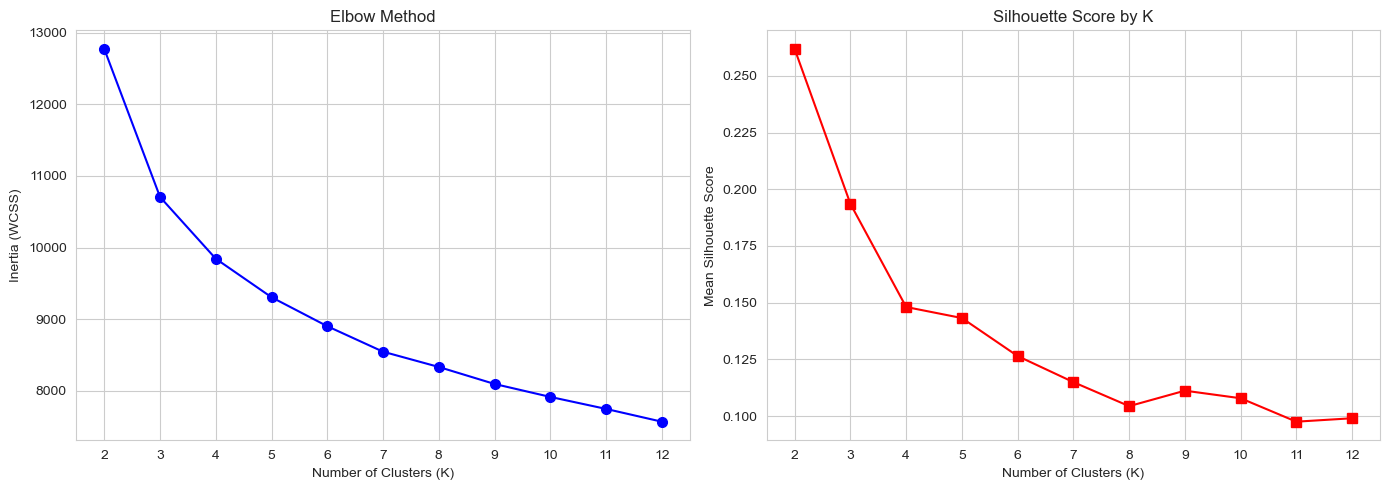


Best K by silhouette: 2 (score=0.2618)
Note: as in Kalman & Bosch, silhouette tends to favor few clusters. We proceed with model-based clustering (GMM) as the primary method.


In [ ]:
K_RANGE = range(2, 13)
inertias = []
silhouettes_km = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X_scaled, labels))
    print(f"K={k:2d}: inertia={km.inertia_:10.1f}  silhouette={silhouettes_km[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, 'bo-', markersize=7)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), silhouettes_km, 'rs-', markersize=7)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[np.argmax(silhouettes_km)]
print(f"\nBest K by silhouette: {best_k} (score={max(silhouettes_km):.4f})")

## 4. Model-Based Clustering (Gaussian Mixture Model)

We use model-based clustering where the number of clusters and covariance structure are selected as a **model selection problem** via BIC (Bayesian Information Criterion).

The GMM fits a mixture of Gaussian distributions, each representing a cluster. The covariance types tested:
- **full** — each cluster has its own unconstrained covariance (ellipsoidal, different shape/orientation)
- **tied** — all clusters share the same covariance (ellipsoidal, same shape)
- **diag** — diagonal covariance (axis-aligned ellipsoids)
- **spherical** — isotropic, like K-Means

BIC penalizes model complexity, so it naturally balances fit vs. number of parameters.

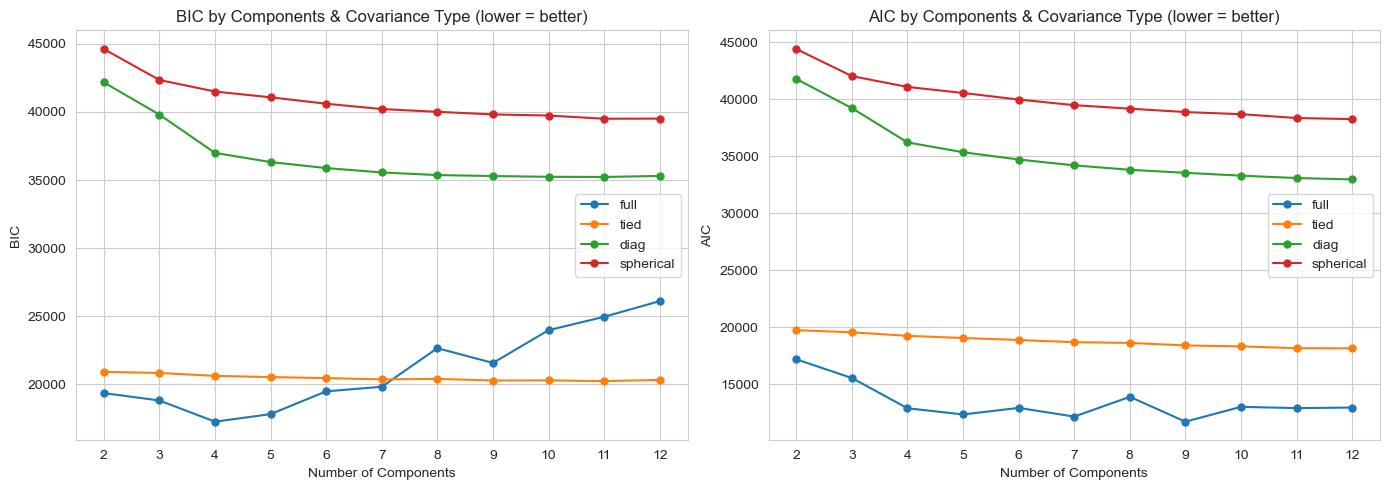

Best by BIC: 4 components, covariance='full', BIC=17267.9


In [ ]:
# BIC model selection: number of components x covariance type
N_RANGE = range(2, 13)
cov_types = ['full', 'tied', 'diag', 'spherical']

results = []
for cov in cov_types:
    for n in N_RANGE:
        gmm = GaussianMixture(n_components=n, covariance_type=cov,
                              n_init=5, random_state=42, max_iter=300)
        gmm.fit(X_scaled)
        results.append({
            'n_components': n,
            'covariance_type': cov,
            'BIC': gmm.bic(X_scaled),
            'AIC': gmm.aic(X_scaled),
        })

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cov in cov_types:
    subset = results_df[results_df['covariance_type'] == cov]
    axes[0].plot(subset['n_components'], subset['BIC'], 'o-', label=cov, markersize=5)
    axes[1].plot(subset['n_components'], subset['AIC'], 'o-', label=cov, markersize=5)

for ax, metric in zip(axes, ['BIC', 'AIC']):
    ax.set_xlabel('Number of Components')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Components & Covariance Type (lower = better)')
    ax.legend()
    ax.set_xticks(list(N_RANGE))

plt.tight_layout()
plt.show()

best_bic = results_df.loc[results_df['BIC'].idxmin()]
print(f"Best by BIC: {int(best_bic['n_components'])} components, "
      f"covariance='{best_bic['covariance_type']}', BIC={best_bic['BIC']:.1f}")

### 4.1 Fit Final GMM

Using the BIC-optimal configuration, we fit the final GMM and assign each player-season a hard cluster label alongside a full probability vector across all clusters. The probability vector enables the soft assignment analysis in Section 6.

In [66]:
# Fit final GMM with BIC-optimal parameters
GMM_N = int(best_bic['n_components'])
GMM_COV = best_bic['covariance_type']
print(f"Fitting GMM: {GMM_N} components, covariance='{GMM_COV}'")

gmm_final = GaussianMixture(n_components=GMM_N, covariance_type=GMM_COV,
                            n_init=10, random_state=42, max_iter=500)
gmm_final.fit(X_scaled)

# Hard assignment
df_filtered['cluster'] = gmm_final.predict(X_scaled)

# Soft assignment: full probability matrix
proba = gmm_final.predict_proba(X_scaled)
df_filtered['cluster_prob_max'] = proba.max(axis=1)

# Store all cluster probabilities
for c in range(GMM_N):
    df_filtered[f'prob_cluster_{c}'] = proba[:, c]

print(f"\nCluster distribution:")
cluster_counts = df_filtered['cluster'].value_counts().sort_index()
for c, count in cluster_counts.items():
    print(f"  Cluster {c}: {count:4d} player-seasons ({100*count/len(df_filtered):.1f}%)")
print(f"\nSilhouette score: {silhouette_score(X_scaled, df_filtered['cluster']):.4f}")

Fitting GMM: 4 components, covariance='full'

Cluster distribution:
  Cluster 0:  291 player-seasons (34.0%)
  Cluster 1:  301 player-seasons (35.2%)
  Cluster 2:  184 player-seasons (21.5%)
  Cluster 3:   80 player-seasons (9.3%)

Silhouette score: 0.1389


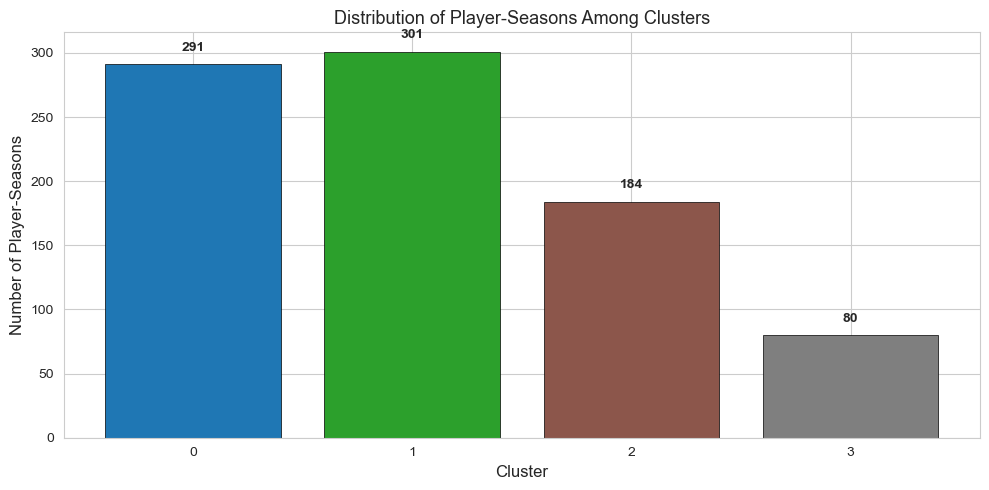

In [ ]:
# Distribution of player-season counts among clusters
fig, ax = plt.subplots(figsize=(10, 5))
counts = df_filtered['cluster'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=plt.cm.tab10(np.arange(GMM_N) / GMM_N),
              edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Number of Player-Seasons Among Clusters', fontsize=13)
ax.set_xticks(range(GMM_N))
plt.tight_layout()
plt.show()

## 5. Cluster Profiling — Exploratory Data Analysis

We visualize each cluster's **scaled variable distributions** using box plots. Values above 0 (green) are above the overall average; values below 0 (red) are below average. This reveals the distinctive traits of each cluster.

We generate one summary plot per cluster showing all 20 variables.

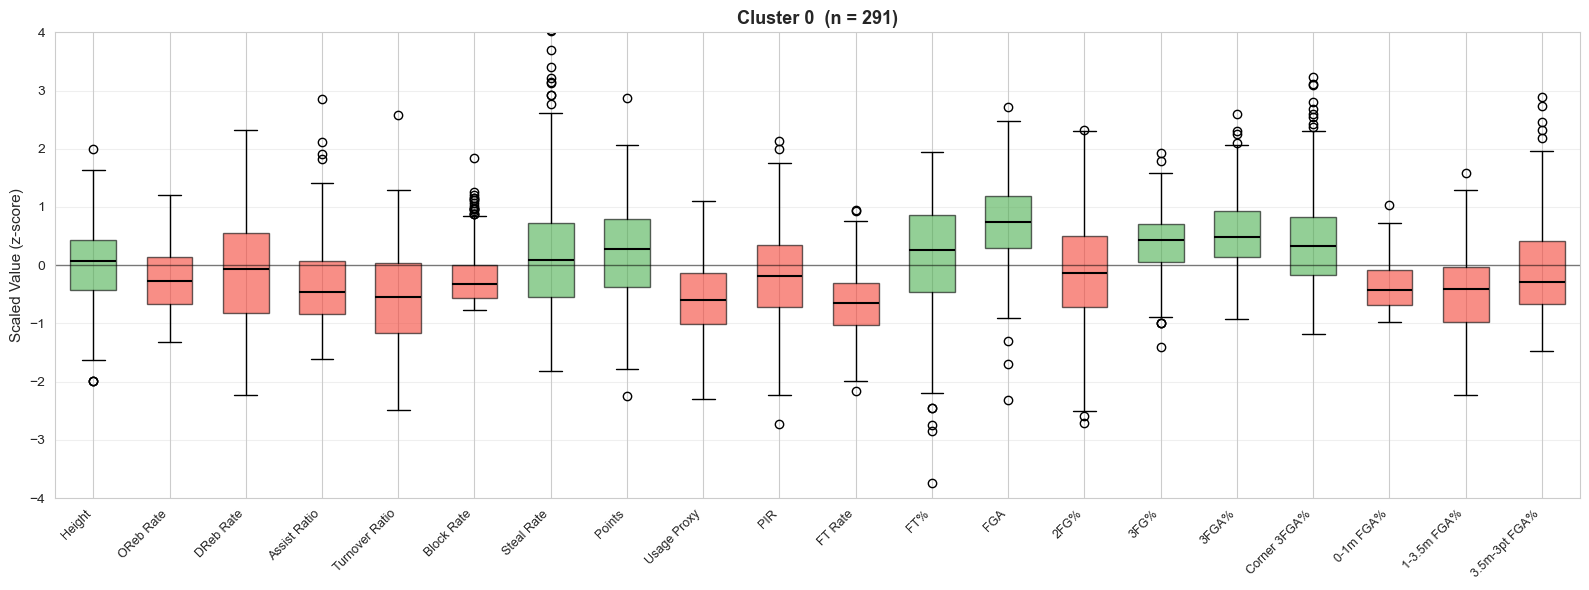

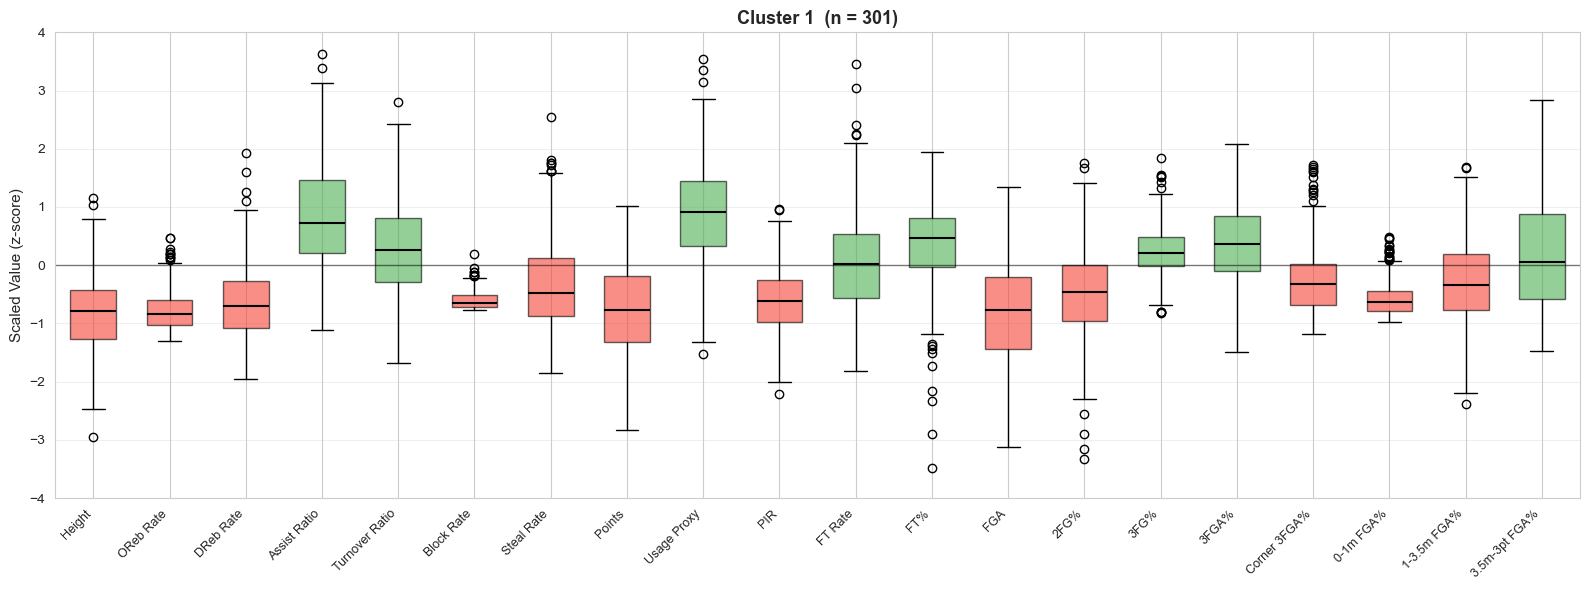

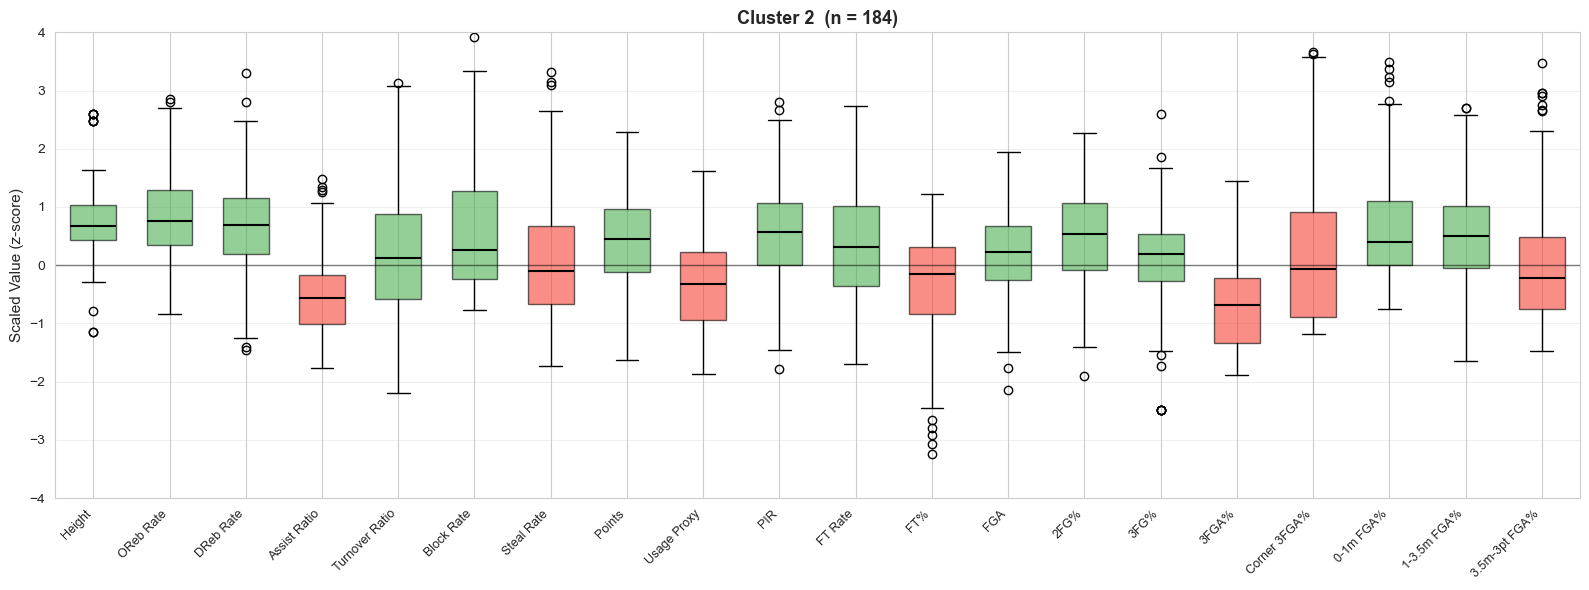

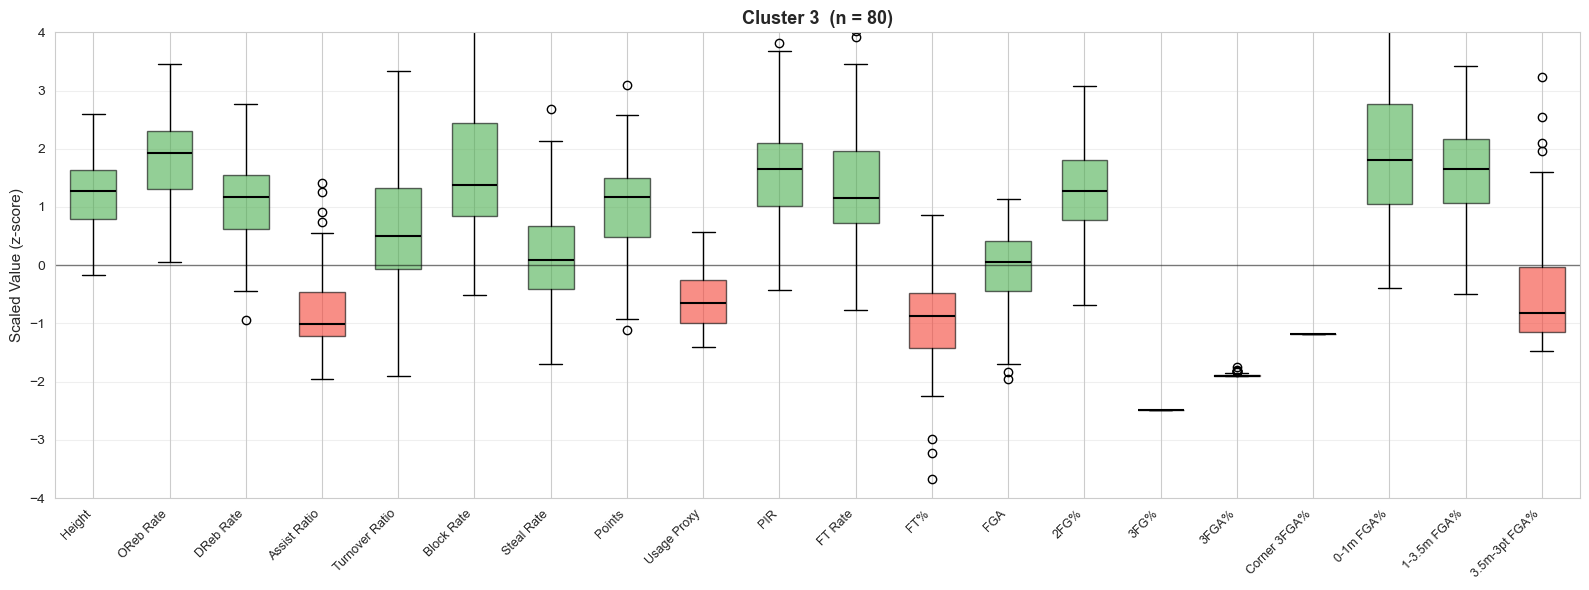

In [67]:
def plot_cluster_profile(cluster_id, X_scaled, labels, var_labels, cluster_name=None):
    """
    Box plot of scaled variables for a single cluster (Kalman Fig. 4 style).
    Boxes colored green if median > 0 (above avg), red if median < 0 (below avg).
    """
    mask = labels == cluster_id
    data = X_scaled.loc[mask]
    n_players = mask.sum()
    
    readable = [var_labels.get(c, c) for c in data.columns]
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    bp = ax.boxplot([data[col].values for col in data.columns],
                    vert=True, patch_artist=True, widths=0.6,
                    medianprops=dict(color='black', linewidth=1.5))
    
    # Color each box green/red based on median
    medians = [data[col].median() for col in data.columns]
    for patch, med in zip(bp['boxes'], medians):
        if med >= 0:
            patch.set_facecolor('#4CAF50')  # green
            patch.set_alpha(0.6)
        else:
            patch.set_facecolor('#F44336')  # red
            patch.set_alpha(0.6)
    
    ax.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)
    ax.set_xticklabels(readable, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Scaled Value (z-score)', fontsize=11)
    
    title = f'Cluster {cluster_id}'
    if cluster_name:
        title += f' — {cluster_name}'
    title += f'  (n = {n_players})'
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(-4, 4)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot all clusters
for c in sorted(df_filtered['cluster'].unique()):
    plot_cluster_profile(c, X_scaled, df_filtered['cluster'], VAR_LABELS)

In [81]:
# Example players per cluster (top 10 by minutes))
print("Top players per cluster (by minutes played):\n")
for c in sorted(df_filtered['cluster'].unique()):
    subset = df_filtered[df_filtered['cluster'] == c]
    top = subset.nlargest(10, 'minutesPlayed')[['player.name', 'season', 'minutesPlayed', 'cluster_prob_max']]
    print(f"--- Cluster {c} (n={len(subset)}) ---")
    for _, row in top.iterrows():
        print(f"  {row['player.name']:30s} {int(row['season'])}  "
              f"({row['minutesPlayed']:.1f} min, prob={row['cluster_prob_max']:.2f})")
    print()

Top players per cluster (by minutes played):

--- Cluster 0 (n=291) ---
  CLYBURN, WILL                  2022  (33.1 min, prob=0.99)
  HAYES-DAVIS, NIGEL             2023  (31.5 min, prob=0.99)
  HAYES-DAVIS, NIGEL             2024  (31.3 min, prob=0.99)
  LEDAY, ZACH                    2022  (30.9 min, prob=0.96)
  PAPAPETROU, IOANNIS            2020  (30.7 min, prob=0.94)
  HAYES-DAVIS, NIGEL             2022  (30.5 min, prob=0.93)
  VEZENKOV, SASHA                2021  (30.2 min, prob=1.00)
  SHIELDS, SHAVON                2021  (29.8 min, prob=0.98)
  POLONARA, ACHILLE              2020  (29.8 min, prob=0.88)
  HEZONJA, MARIO                 2021  (29.6 min, prob=0.83)

--- Cluster 1 (n=301) ---
  SHVED, ALEXEY                  2020  (32.5 min, prob=1.00)
  LARKIN, SHANE                  2021  (31.9 min, prob=1.00)
  JAMES, MIKE                    2023  (31.7 min, prob=1.00)
  LARKIN, SHANE                  2023  (31.6 min, prob=1.00)
  BROWN, LORENZO                 2022  (31.6 mi

In [69]:
# Cluster means summary table (original scale) for interpretation
profile = df_filtered.groupby('cluster')[CLUSTER_VARS + ['minutesPlayed']].mean()
profile_display = profile.rename(columns=VAR_LABELS).T
profile_display.columns = [f'Cluster {c}' for c in profile_display.columns]
display(profile_display.round(3))

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Height,199.856,192.309,205.902,210.212
OReb Rate,0.043,0.024,0.082,0.120
DReb Rate,0.125,0.101,0.159,0.179
Assist Ratio,0.139,0.237,0.126,0.105
Turnover Ratio,0.100,0.127,0.123,0.138
Block Rate,2.068,0.605,5.332,9.041
Steal Rate,7.804,6.138,7.486,7.379
Points,87.938,71.832,90.318,99.605
Usage Proxy,0.409,0.604,0.444,0.402
PIR,85.745,73.173,107.740,138.700


In [70]:
# Identify high/low stats per cluster (scaled means) for table description
scaled_means = df_filtered.groupby('cluster')[CLUSTER_VARS].apply(
    lambda g: pd.Series(g.values.mean(axis=0), index=CLUSTER_VARS)
)
# Use the scaled data to compute cluster means in z-score space
scaled_cluster_means = X_scaled.groupby(df_filtered['cluster']).mean()

print("Scaled cluster means (z-scores) — used to identify high/low stats:\n")
for c in sorted(scaled_cluster_means.index):
    row = scaled_cluster_means.loc[c]
    high = row[row > 0.4].sort_values(ascending=False)
    low = row[row < -0.4].sort_values()
    
    high_str = ', '.join([f"{VAR_LABELS.get(v, v)} ({row[v]:+.2f})" for v in high.index[:5]])
    low_str = ', '.join([f"{VAR_LABELS.get(v, v)} ({row[v]:+.2f})" for v in low.index[:5]])
    
    print(f"Cluster {c}:")
    print(f"  HIGH: {high_str}")
    print(f"  LOW:  {low_str}")
    print()

Scaled cluster means (z-scores) — used to identify high/low stats:

Cluster 0:
  HIGH: FGA (+0.72), 3FGA% (+0.56), Corner 3FGA% (+0.42)
  LOW:  FT Rate (-0.65), Turnover Ratio (-0.58), Usage Proxy (-0.56), 1-3.5m FGA% (-0.49)

Cluster 1:
  HIGH: Usage Proxy (+0.89), Assist Ratio (+0.85)
  LOW:  Height (-0.86), FGA (-0.82), Points (-0.77), OReb Rate (-0.76), DReb Rate (-0.64)

Cluster 2:
  HIGH: OReb Rate (+0.82), Height (+0.77), DReb Rate (+0.69), Block Rate (+0.65), 0-1m FGA% (+0.63)
  LOW:  3FGA% (-0.70), Assist Ratio (-0.51)

Cluster 3:
  HIGH: 0-1m FGA% (+1.96), OReb Rate (+1.86), 1-3.5m FGA% (+1.64), Block Rate (+1.64), PIR (+1.62)
  LOW:  3FG% (-2.50), 3FGA% (-1.89), Corner 3FGA% (-1.18), FT% (-0.95), Assist Ratio (-0.77)



### 5.1 New Positions Description Table

We summarize each cluster into a **new position** with high/low stats and example players. Based on the stat profiles above, the four clusters are named: **Perimeter Shooter** (Cluster 0), **Ball Handler** (Cluster 1), **Two-Way Forward** (Cluster 2), and **Rim Protector** (Cluster 3).

In [ ]:
# New positions description table

# Placeholder names
position_names = {
    0: "Perimeter Shooter",
    1: "Ball Handler",
    2: "Two-Way Forward",
    3: "Rim Protector"
}

# Build table data
table_rows = []
for c in sorted(scaled_cluster_means.index):
    row = scaled_cluster_means.loc[c]
    
    # Top 3 high and low stats
    high = row[row > 0.3].sort_values(ascending=False)
    low = row[row < -0.3].sort_values()
    high_stats = ', '.join([VAR_LABELS.get(v, v) for v in high.index[:4]])
    low_stats = ', '.join([VAR_LABELS.get(v, v) for v in low.index[:4]])
    
    # Example players (top 10 by minutes with high probability)
    subset = df_filtered[(df_filtered['cluster'] == c) & (df_filtered['cluster_prob_max'] > 0.6)]
    if len(subset) < 3:
        subset = df_filtered[df_filtered['cluster'] == c]
    top_players = subset.nlargest(5, 'minutesPlayed')
    examples = ', '.join([f"{r['player.name']} ({int(r['season'])})" 
                          for _, r in top_players.iterrows()])
    
    n = (df_filtered['cluster'] == c).sum()
    
    table_rows.append({
        'Cluster': c,
        'New Position': position_names[c],
        'N': n,
        'High Stats': high_stats,
        'Low Stats': low_stats,
        'Example Players': examples
    })

positions_table = pd.DataFrame(table_rows)
positions_table = positions_table.set_index('Cluster')

# Display as a styled table
display(positions_table.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'normal',
    'max-width': '250px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
]))

,New Position,N,High Stats,Low Stats,Example Players
Cluster,,,,,
0,Perimeter Shooter,291,"FGA, 3FGA%, Corner 3FGA%, 3FG%","FT Rate, Turnover Ratio, Usage Proxy, 1-3.5m FGA%","CLYBURN, WILL (2022), HAYES-DAVIS, NIGEL (2023), HAYES-DAVIS, NIGEL (2024), LEDAY, ZACH (2022), PAPAPETROU, IOANNIS (2020)"
1,Ball Handler,301,"Usage Proxy, Assist Ratio, 3FGA%, FT%","Height, FGA, Points, OReb Rate","SHVED, ALEXEY (2020), LARKIN, SHANE (2021), JAMES, MIKE (2023), LARKIN, SHANE (2023), BROWN, LORENZO (2022)"
2,Two-Way Forward,184,"OReb Rate, Height, DReb Rate, Block Rate","3FGA%, Assist Ratio, Usage Proxy","LUCIC, VLADIMIR (2020), BROWN III, JOHN (2021), HOARD, JAYLEN (2024), VEZENKOV, SASHA (2024), LUCIC, VLADIMIR (2021)"
3,Rim Protector,80,"0-1m FGA%, OReb Rate, 1-3.5m FGA%, Block Rate","3FG%, 3FGA%, Corner 3FGA%, FT%","LESSORT, MATHIAS (2022), LESSORT, MATHIAS (2023), PAPAGIANNIS, GEORGIOS (2021), VESELY, JAN (2020), TAVARES, WALTER (2020)"


## 6. Soft Assignment — Cluster Likelihood Mapping

A key advantage of model-based clustering over K-Means: each player gets a **probabilistic distribution** across all clusters, not just a hard assignment. Some players map strongly to one cluster, while others are "in between". These hybrid players are often the most interesting.

Players with max prob >= 0.5: 100.0%
Players with max prob >= 0.7: 98.1%
Players with max prob >= 0.9: 92.9%


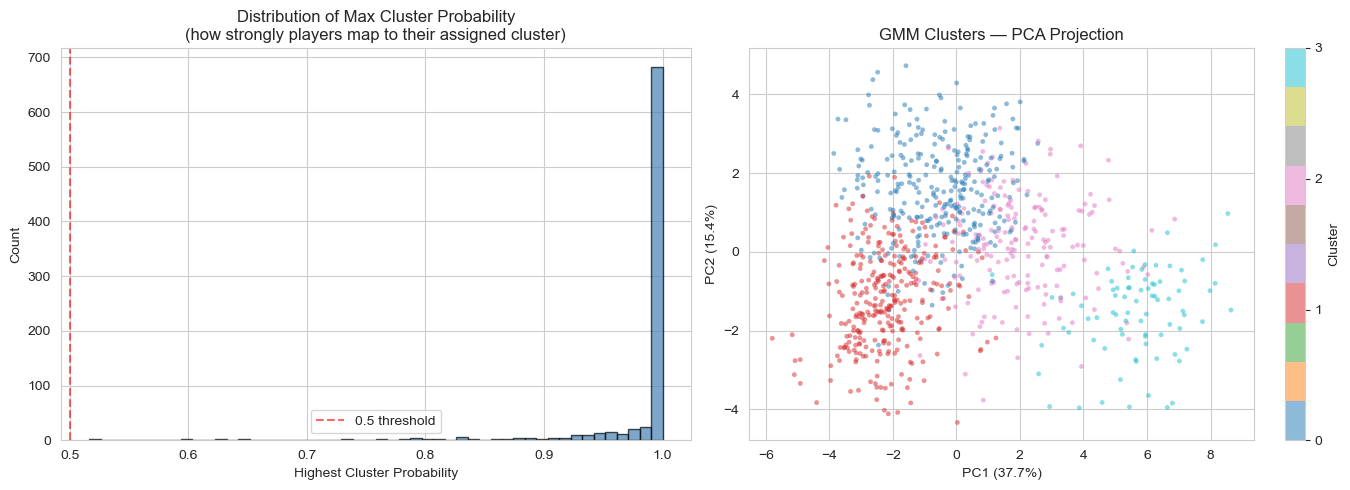

In [ ]:
# Distribution of max cluster probability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_filtered['cluster_prob_max'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Highest Cluster Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Max Cluster Probability\n(how strongly players map to their assigned cluster)')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.6, label='0.5 threshold')
axes[0].legend()

# % above thresholds
for thresh in [0.5, 0.7, 0.9]:
    pct = (df_filtered['cluster_prob_max'] >= thresh).mean() * 100
    print(f"Players with max prob >= {thresh}: {pct:.1f}%")

# PCA colored by cluster
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=df_filtered['cluster'], cmap='tab10',
                          alpha=0.5, s=12, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('GMM Clusters — PCA Projection')
plt.colorbar(scatter, ax=axes[1], label='Cluster', ticks=range(GMM_N))

plt.tight_layout()
plt.show()

In [ ]:
# "In-between" players
uncertain = df_filtered[df_filtered['cluster_prob_max'] < 0.6].copy()
uncertain = uncertain.sort_values('cluster_prob_max')

print(f"Players with max cluster probability < 0.6: {len(uncertain)}\n")
print("Most 'in-between' players (split across multiple clusters):\n")

prob_cols = [f'prob_cluster_{c}' for c in range(GMM_N)]
for _, row in uncertain.head(15).iterrows():
    probs = {c: row[f'prob_cluster_{c}'] for c in range(GMM_N)}
    top2 = sorted(probs.items(), key=lambda x: -x[1])[:2]
    print(f"  {row['player.name']:30s} {int(row['season'])}  — "
          f"Cluster {top2[0][0]}: {top2[0][1]:.0%}, "
          f"Cluster {top2[1][0]}: {top2[1][1]:.0%}")

Players with max cluster probability < 0.6: 7

Most 'in-between' players (split across multiple clusters):

  BACON, DWAYNE                  2022  — Cluster 1: 52%, Cluster 0: 48%
  PAPANIKOLAOU, KOSTAS           2023  — Cluster 0: 52%, Cluster 1: 48%
  DOBRIC, OGNJEN                 2021  — Cluster 1: 54%, Cluster 0: 46%
  BROWN, STERLING                2023  — Cluster 0: 56%, Cluster 1: 44%
  GIFFEY, NIELS                  2020  — Cluster 2: 58%, Cluster 0: 42%
  OLINDE, LOUIS                  2021  — Cluster 2: 59%, Cluster 0: 41%
  CLYBURN, WILL                  2020  — Cluster 1: 60%, Cluster 2: 39%
